In [3]:
import pandas as pd
from sqlalchemy import create_engine

# 1. ดึงค่า Config จากไฟล์แรก
%store -r DB_CONFIG

# 2. เชื่อมต่อ Engine
engine = create_engine(f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}")

# 3. ดึงข้อมูลมาเช็ค
df = pd.read_sql("SELECT * FROM stock_prices ORDER BY ticker, date", engine)
df['date'] = pd.to_datetime(df['date'])

print(f"📊 ดึงข้อมูลสำเร็จ! ตอนนี้มีข้อมูลทั้งหมด {len(df)} แถว")
print(f"📈 หุ้นที่พร้อมวิเคราะห์: {df['ticker'].unique()}")

📊 ดึงข้อมูลสำเร็จ! ตอนนี้มีข้อมูลทั้งหมด 6395 แถว
📈 หุ้นที่พร้อมวิเคราะห์: ['ADVANC' 'AOT' 'BDMS' 'KBANK' 'PTT']


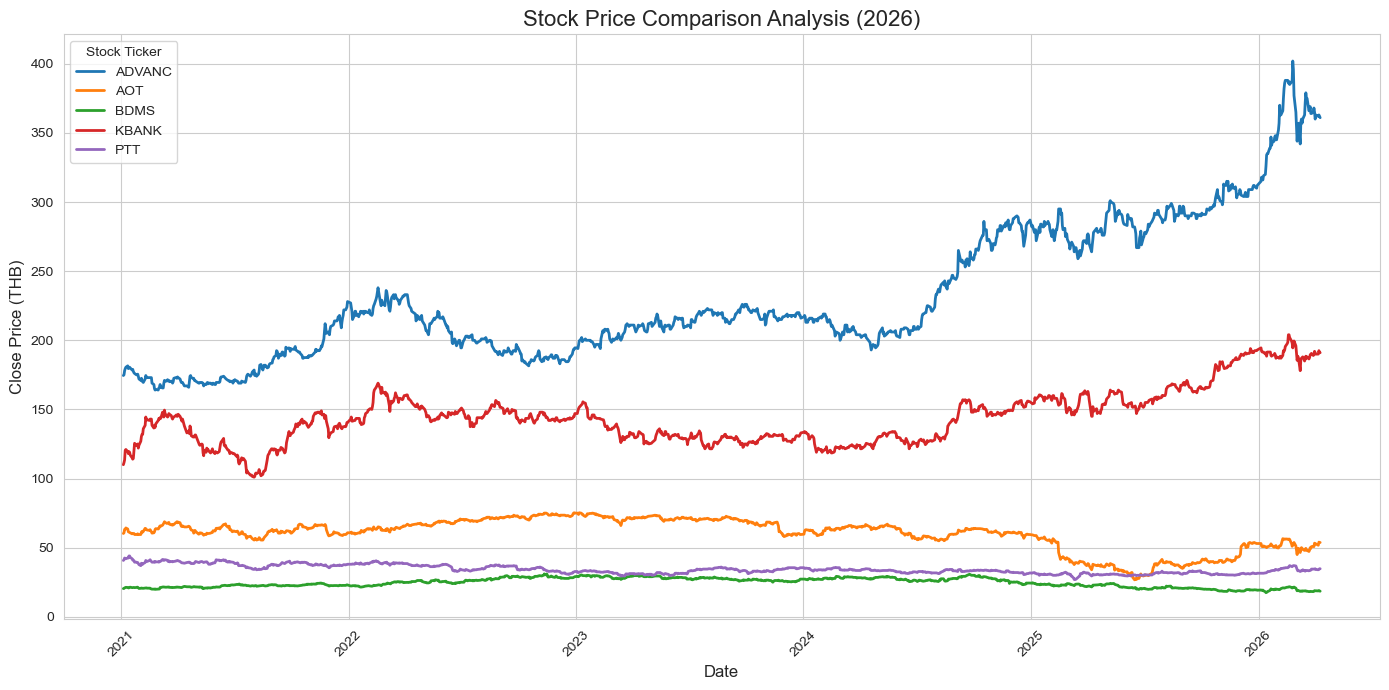

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าความสวยงาม
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# วาดกราฟราคาปิดของหุ้นทุกตัว
for ticker in df['ticker'].unique():
    subset = df[df['ticker'] == ticker]
    plt.plot(subset['date'], subset['close_price'], label=ticker, linewidth=2)

plt.title('Stock Price Comparison Analysis (2026)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price (THB)', fontsize=12)
plt.legend(title='Stock Ticker')
plt.xticks(rotation=45)
plt.tight_layout()

# บันทึกรูปไว้ใช้ในรายงาน
plt.savefig('stock_analysis_result.png')
plt.show()

In [5]:
# สรุปราคา ต่ำสุด-สูงสุด-เฉลี่ย
summary = df.groupby('ticker')['close_price'].agg(['min', 'max', 'mean']).round(2)
summary.columns = ['ราคาต่ำสุด', 'ราคาสูงสุด', 'ราคาเฉลี่ย']

print("📊 ตารางสรุปภาพรวมราคาหุ้น:")
display(summary)

📊 ตารางสรุปภาพรวมราคาหุ้น:


,ราคาต่ำสุด,ราคาสูงสุด,ราคาเฉลี่ย
ticker,,,
ADVANC,164.00,402.00,231.33
AOT,26.75,75.25,60.17
BDMS,17.40,31.00,24.68
KBANK,101.00,204.00,144.14
PTT,27.00,44.00,34.30


In [7]:
# คำนวณผลตอบแทนรายวัน (Daily Return %)
df['daily_return'] = df.groupby('ticker')['close_price'].pct_change() * 100

# คำนวณเส้นค่าเฉลี่ย 5 วัน และ 20 วัน
df['MA5'] = df.groupby('ticker')['close_price'].transform(lambda x: x.rolling(window=5).mean())
df['MA20'] = df.groupby('ticker')['close_price'].transform(lambda x: x.rolling(window=20).mean())

print("✅ สร้างคอลัมน์ daily_return และเส้น MA เรียบร้อยแล้ว!")
display(df.tail())

✅ สร้างคอลัมน์ daily_return และเส้น MA เรียบร้อยแล้ว!


,id,ticker,date,open_price,high_price,low_price,close_price,volume,daily_return,MA5,MA20
6390,5,PTT,2026-04-03,34.25,35.50,35.50,34.25,-3,-1.438849,34.50,33.7125
6391,4,PTT,2026-04-07,34.75,34.25,35.25,34.00,1,-0.729927,34.40,33.7750
6392,3,PTT,2026-04-08,35.00,34.50,35.25,34.25,0,0.735294,34.35,33.8250
6393,2,PTT,2026-04-09,35.50,35.00,35.50,34.75,1,1.459854,34.40,33.9000
6394,1,PTT,2026-04-10,34.75,35.25,35.25,34.75,-2,0.000000,34.40,33.9750


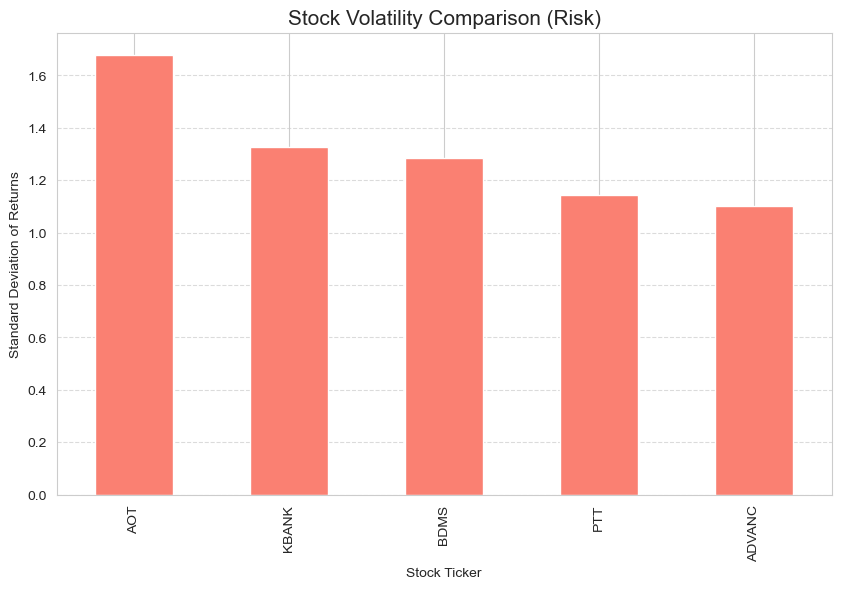

💡 หุ้นที่มีค่าสูงคือหุ้นที่มีความเสี่ยงหรือความผันผวนสูงครับ


In [8]:
# คำนวณความผันผวน (Volatility) จากผลตอบแทนรายวัน
volatility = df.groupby('ticker')['daily_return'].std().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
volatility.plot(kind='bar', color='salmon')
plt.title('Stock Volatility Comparison (Risk)', fontsize=15)
plt.ylabel('Standard Deviation of Returns')
plt.xlabel('Stock Ticker')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("💡 หุ้นที่มีค่าสูงคือหุ้นที่มีความเสี่ยงหรือความผันผวนสูงครับ")

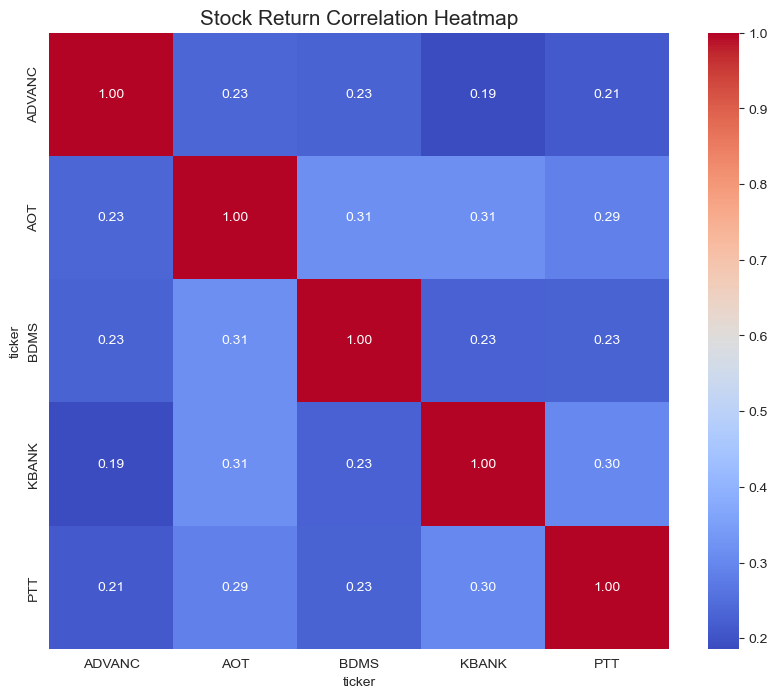

In [9]:
import seaborn as sns

# เตรียมข้อมูลสำหรับ Heatmap
pivot_df = df.pivot(index='date', columns='ticker', values='close_price')
corr_matrix = pivot_df.pct_change().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Stock Return Correlation Heatmap', fontsize=15)
plt.show()